In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
nodes = pd.read_csv("nodes.csv")
edges = pd.read_csv("edges.csv")

print(nodes.shape, edges.shape)

(341070, 7) (192184, 6)


In [10]:
seed_nodes = set(nodes.sample(n=100, random_state=42)["Id"])

current_nodes = seed_nodes.copy()

for _ in range(3):  # 👈 number of hops (tune this)
    new_edges = edges[
        edges["Source"].isin(current_nodes) |
        edges["Target"].isin(current_nodes)
    ]
    
    new_nodes = set(new_edges["Source"]).union(new_edges["Target"])
    
    current_nodes = current_nodes.union(new_nodes)

# final subgraph
sample_edges = edges[
    edges["Source"].isin(current_nodes) &
    edges["Target"].isin(current_nodes)
]

sample_nodes = nodes[nodes["Id"].isin(current_nodes)]

print("Nodes:", len(sample_nodes))
print("Edges:", len(sample_edges))

Nodes: 46617
Edges: 53783


In [11]:
import networkx as nx

G = nx.from_pandas_edgelist(
    sample_edges,
    source="Source",
    target="Target",
    create_using=nx.DiGraph()
)

In [12]:
# keep only important nodes (by degree)
degree_dict = dict(G.degree())

top_nodes = sorted(degree_dict, key=degree_dict.get, reverse=True)[:800]

G_vis = G.subgraph(top_nodes).copy()

print("Viz graph:", G_vis.number_of_nodes(), G_vis.number_of_edges())

Viz graph: 800 2162


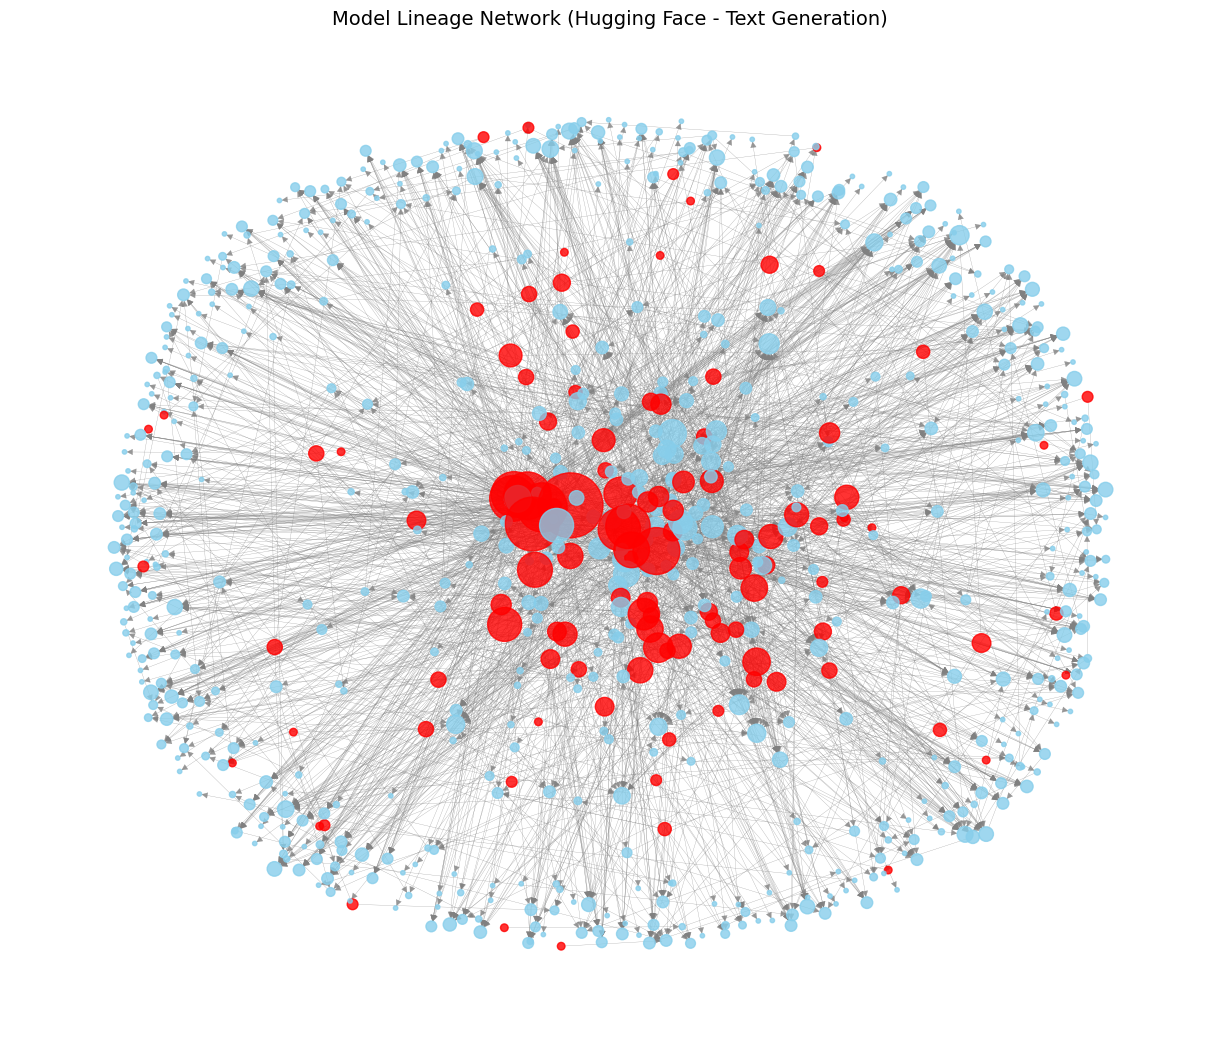

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

pos = nx.spring_layout(G_vis, seed=42, k=0.4)

degrees = dict(G_vis.degree())
node_colors = []
node_sizes = []

for n in G_vis.nodes():
    deg = G_vis.degree(n)
    
    if G_vis.in_degree(n) == 0:
        node_colors.append("red")
        node_sizes.append(deg * 30)  # bigger for base
    else:
        node_colors.append("skyblue")
        node_sizes.append(deg * 10)

nx.draw(
    G_vis,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    edge_color="gray",
    width=0.2,
    alpha=0.8,
    with_labels=True
)

plt.title("Model Lineage Network (Hugging Face - Text Generation)", fontsize=14)
plt.show()